In [4]:
import numpy as np
import matplotlib.pyplot as plt

%precision 3
%matplotlib inline

In [5]:
x_set = np.array([1, 2, 3, 4, 5,  6])

In [6]:
def f(x):
    if x in x_set:
        return x / 21
    else:return 0

In [7]:
# 확률 변수
X = [x_set, f]

In [8]:
prob = np.array([f(x_k) for x_k in x_set])
dict(zip(x_set, prob))

{np.int64(1): 0.048,
 np.int64(2): 0.095,
 np.int64(3): 0.143,
 np.int64(4): 0.190,
 np.int64(5): 0.238,
 np.int64(6): 0.286}

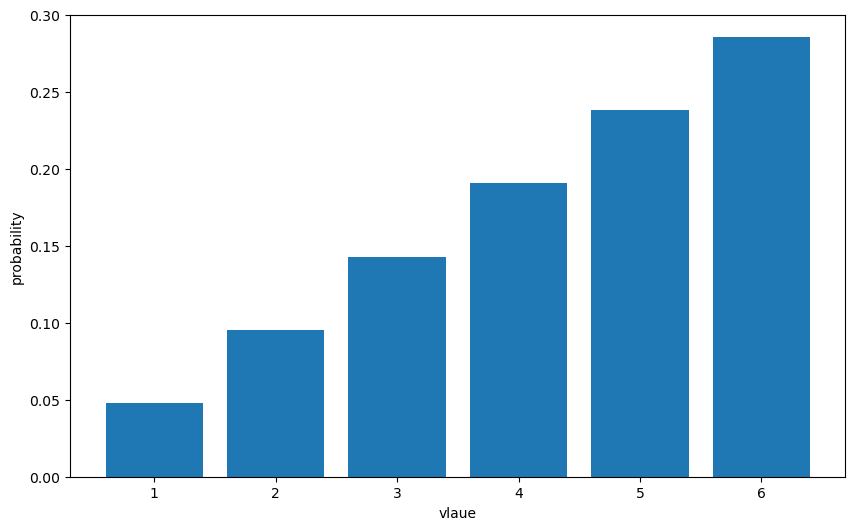

In [9]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.bar(x_set, prob)
ax.set_xlabel('vlaue')
ax.set_ylabel('probability')

plt.show()

In [10]:
# 파이썬 문법 실습

In [11]:
a = {'사과':1, '딸기':5, '귤':10}
a

{'사과': 1, '딸기': 5, '귤': 10}

In [12]:
a = {('초콜릿', 200):20, ('마카롱', 500):15, ('쿠키', 300):30}
a

{('초콜릿', 200): 20, ('마카롱', 500): 15, ('쿠키', 300): 30}

In [13]:
a = {'사과':1, '딸기':5, '귤':10}
v1 = a['딸기']
v1

5

In [14]:
v1 = a['레몬']
v1

KeyError: '레몬'

In [ ]:
f1 = '딸기' in a
f1

In [ ]:
f2 = '레몬' not in a
f2

In [15]:
f3 = '레몬' in a
f3

False

In [16]:
v1 = a.get('딸기')
v1

5

In [17]:
v2 = a.get('레몬')
v2

In [18]:
a = {'초콜릿':1, '마카롱':2, '쿠키':3}
a['초콜릿'] = 'One'
a['마카롱'] = 'Two'
a['쿠키'] = 'Three'
a

{'초콜릿': 'One', '마카롱': 'Two', '쿠키': 'Three'}

In [19]:
d = dict(초콜릿 = 20, 마카롱 = 15, 쿠키 = 30)
d

{'초콜릿': 20, '마카롱': 15, '쿠키': 30}

In [20]:
key = ['초콜릿', '마카롱', '쿠키']
value = [20, 15, 30]
d = dict(zip(key, value))
d

{'초콜릿': 20, '마카롱': 15, '쿠키': 30}

In [21]:
d = dict([('초콜릿', 20), ('마카로', 15), ('쿠키', 30)])
d

{'초콜릿': 20, '마카로': 15, '쿠키': 30}

In [22]:
# 확률의 성질 (확률은 절대적으로 0 이상이고, 모든 확률은 더하면 1이 된다)

In [23]:
np.all(prob >= 0)

np.True_

In [24]:
np.sum(prob)

1.000

In [25]:
# 누적분포함수

In [26]:
def F(x):
    return np.sum([f(x_k) for x_k in x_set if x_k <= x])

In [27]:
F(3)

0.286

In [28]:
# 확률변수의 변환
# 확률변수의 변환(곱하거나 더하거나 등)을 정의할 수 있고(가능하고), 변환한 후에도 여전히 확률변수임 !!

In [29]:
y_set = np.array([2 * x_k + 3 for x_k in x_set])
prob = np.array([f(x_k) for x_k in x_set])
dict(zip(y_set, prob))

{np.int64(5): 0.048,
 np.int64(7): 0.095,
 np.int64(9): 0.143,
 np.int64(11): 0.190,
 np.int64(13): 0.238,
 np.int64(15): 0.286}

In [30]:
# 기대값

In [31]:
np.sum([x_k * f(x_k) for x_k in x_set])

4.333

In [32]:
# 데이터 샘플링

In [33]:
np.random.choice(5, 5, replace=False)

array([0, 3, 2, 1, 4], dtype=int32)

In [34]:
np.random.choice(5, 3, replace=False)

array([3, 0, 2], dtype=int32)

In [35]:
np.random.choice(5, 10)

array([1, 3, 1, 3, 1, 0, 3, 4, 4, 0], dtype=int32)

In [36]:
# 선택 확률을 다르게 해서 10개 선택)
np.random.choice(5, 10, p=[0.1, 0, 0.3, 0.6, 0])

array([3, 3, 2, 3, 0, 3, 3, 0, 3, 3], dtype=int32)

In [37]:
# 기대값 (다른 식으로 계산)

In [38]:
sample = np.random.choice(x_set, int(1e6), p=prob)
np.mean(sample)

4.334

In [39]:
# 기대값 (수식을 기대값의 함수로 구하기)

In [40]:
def E(X, g=lambda x: x):
    x_set, f = X
    return np.sum([g(x_k) * f(x_k) for x_k in x_set])

E(X)

4.333

In [41]:
# 확률변수 Y = 2X + 3 의 기대값

In [42]:
E(X, g=lambda x: 2*x + 3)

11.667

In [43]:
2 * E(X) + 3

11.667

In [44]:
# 람다함수 실습

In [45]:
strings = ['hyeja', 'parkhyeja', 'youngtae', 'kimyoungtae', 'bbangtae']
strings.sort(key=lambda x: len(set(list(x))))
strings

['hyeja', 'bbangtae', 'parkhyeja', 'youngtae', 'kimyoungtae']

In [46]:
# 분산

In [47]:
mean = E(X)
np.sum([(x_k - mean)**2 * f(x_k) for x_k in x_set])

2.222

In [48]:
# 인수 g가 확률변수에 대한 변환의 함수

In [49]:
def V(X, g=lambda x: x):
    x_set, f = X
    mean = E(X, g)
    return np.sum([(g(x_k) - mean)**2 * f(x_k) for x_k in x_set])

V(X)

2.222

In [50]:
V(X, lambda x: 2*x + 3)

8.889

In [51]:
2**2 * V(X)

8.889